# Instaloader 실전 튜토리얼

이 노트북은 Instaloader를 다양한 방법으로 테스트하고, 수집한 데이터를 분석하는 방법을 다룸.

## 목차
1. [환경 설정](#1-환경-설정)
2. [CLI 기반 테스트](#2-cli-기반-테스트)
3. [Python API 기본 사용법](#3-python-api-기본-사용법)
4. [고급 활용 - 필터링과 커스터마이징](#4-고급-활용---필터링과-커스터마이징)
5. [데이터 분석 - JSON/XZ 파일 읽기](#5-데이터-분석---jsonxz-파일-읽기)
6. [종합 데이터 분석](#6-종합-데이터-분석)
7. [실전 팁과 트러블슈팅](#7-실전-팁과-트러블슈팅)

---

## 1. 환경 설정

In [ ]:
# 필요한 라이브러리 설치 (처음 한 번만 실행)
!pip install instaloader pandas matplotlib seaborn

In [43]:
# 기본 라이브러리 임포트
import instaloader
import json
import lzma
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path
from collections import defaultdict

# 한글 폰트 설정 (matplotlib)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

print(f"Instaloader 버전: {instaloader.__version__}")
print("환경 설정 완료!")

Instaloader 버전: 4.15
환경 설정 완료!


In [44]:
# 작업 디렉토리 설정
WORK_DIR = Path("../instaloader_data")
WORK_DIR.mkdir(exist_ok=True)

print(f"작업 디렉토리: {WORK_DIR.absolute()}")

작업 디렉토리: /workspace/instaloader/my_docs/../instaloader_data


---

## 2. CLI 기반 테스트

주피터 노트북에서 `!` 또는 `%%bash`를 사용하여 CLI 명령어를 실행할 수 있음.

### 2.1 도움말 확인

In [45]:
# Instaloader 버전 및 도움말
!instaloader --version

4.15


In [46]:
# 전체 옵션 보기 (많아서 일부만 보기)
!instaloader --help | head -50

usage: 
instaloader [--comments] [--geotags]
            [--stories] [--highlights] [--tagged] [--reels] [--igtv]
            [--login YOUR-USERNAME] [--fast-update]
            profile | "#hashtag" | %location_id | :stories | :feed | :saved
instaloader --help

Download pictures (or videos) along with their captions and other metadata
from Instagram.

What to Download:
  Specify a list of targets. For each of these, Instaloader creates a folder
  and downloads all posts. The following targets are supported:

  profile               Download profile. If an already-downloaded profile has
                        been renamed, Instaloader automatically finds it by
                        its unique ID and renames the folder likewise.
  @profile              Download all followees of profile. Requires login.
                        Consider using :feed rather than @yourself.
  "#hashtag"            Download #hashtag.
  %location_id          Download %location_id. Requires login.
  :feed    

### 2.2 익명 다운로드 테스트 (로그인 없이)

공개 프로필의 최근 게시글 다운로드

In [47]:
%%bash
cd ../instaloader_data

# 공개 프로필 테스트 (예: instagram 공식 계정)
# --no-video-thumbnails: 비디오 썸네일 제외
# --no-metadata-json: JSON 메타데이터 제외 (빠른 테스트용)
instaloader --no-video-thumbnails instagram

echo "\n다운로드 완료! 파일 목록:"
ls -lh instagram/ | head -10

Stored ID 25025320 for profile instagram.
Hint: Login to download higher-quality versions of pictures.
[1/1] Downloading profile instagram
instagram/2025-09-20_00-00-36_UTC_profile_pic.jpg 
Retrieving posts from profile instagram.
[   1/8237] [Fit recap with @mmiriku (Miri…] instagram/2025-11-17_20-12-51_UTC.mp4 json 
[   2/8237] instagram/2025-11-17_17-00-50_UTC_1.mp4 instagram/2025-11-17_17-00-50_UTC_2.jpg instagram/2025-11-17_17-00-50_UTC_3.mp4 instagram/2025-11-17_17-00-50_UTC_4.jpg instagram/2025-11-17_17-00-50_UTC_5.mp4 instagram/2025-11-17_17-00-50_UTC_6.jpg instagram/2025-11-17_17-00-50_UTC_7.mp4 instagram/2025-11-17_17-00-50_UTC_8.jpg instagram/2025-11-17_17-00-50_UTC_9.mp4 instagram/2025-11-17_17-00-50_UTC_10.jpg [Musician @silvanaestradab (Si…] json 
[   3/8237] instagram/2025-11-16_04-51-37_UTC_1.jpg instagram/2025-11-16_04-51-37_UTC_2.mp4 instagram/2025-11-16_04-51-37_UTC_3.jpg instagram/2025-11-16_04-51-37_UTC_4.mp4 instagram/2025-11-16_04-51-37_UTC_5.jpg instagram/2025-1


Interrupted by user.


\n다운로드 완료! 파일 목록:
total 151M
-rw-r--r-- 1 root root  8.9K Sep 20 09:00 2025-09-20_00-00-36_UTC_profile_pic.jpg
-rw-r--r-- 1 root root   288 Nov 11 03:18 2025-11-10_18-18-33_UTC.txt
-rw-r--r-- 1 root root  4.8K Nov 18 19:29 2025-11-10_20-03-10_UTC.json.xz
-rw-r--r-- 1 root root   26M Nov 11 05:03 2025-11-10_20-03-10_UTC.mp4
-rw-r--r-- 1 root root   381 Nov 11 05:03 2025-11-10_20-03-10_UTC.txt
-rw-r--r-- 1 root root  4.9K Nov 18 19:29 2025-11-11_17-08-16_UTC.json.xz
-rw-r--r-- 1 root root  2.4M Nov 12 02:08 2025-11-11_17-08-16_UTC.mp4
-rw-r--r-- 1 root root   505 Nov 12 02:08 2025-11-11_17-08-16_UTC.txt
-rw-r--r-- 1 root root  4.7K Nov 18 19:29 2025-11-11_21-09-29_UTC.json.xz
Process is interrupted.


### 2.4 해시태그 다운로드

In [49]:
!instaloader --login juhyeokcrawl02 --password maint!@#123

Session file does not exist yet - Logging in.
Logged in as juhyeokcrawl02.
Saved session to /root/.config/instaloader/session-juhyeokcrawl02.
No targets were specified, thus nothing has been downloaded.


In [52]:
!instaloader --sessionfile=session-juhyeokcrawl02 "#python" 

#python: Login required.

Errors or warnings occurred:
#python: Login required.


### 2.5 특정 게시글 다운로드 (shortcode 사용)

In [ ]:
%%bash
cd instaloader_data

# Instagram URL: https://www.instagram.com/p/ABC123xyz/
# shortcode: ABC123xyz
instaloader -- -ABC123xyz

# 실제 예시 (Instagram 공식 계정의 최근 게시글 하나)
# 먼저 shortcode를 알아야 함 (다음 섹션에서 Python API로 확인 가능)

---

## 3. Python API 기본 사용법

### 3.1 Instaloader 인스턴스 생성

In [53]:
# Instaloader 인스턴스 생성 (익명 모드)
L = instaloader.Instaloader(
    dirname_pattern=str(WORK_DIR / "{target}"),  # 저장 경로
    download_pictures=True,          # 이미지 다운로드
    download_videos=False,           # 비디오 제외 (빠른 테스트)
    download_video_thumbnails=False, # 비디오 썸네일 제외
    download_geotags=False,          # 위치 정보 제외
    download_comments=False,         # 댓글 제외 (익명은 불가능)
    save_metadata=True,              # JSON 메타데이터 저장
    compress_json=True,              # JSON 압축 (.xz)
    post_metadata_txt_pattern="",   # txt 파일 생성 안 함
    max_connection_attempts=3,       # 최대 재시도 횟수
)

print(f"Instaloader 준비 완료!")
print(f"로그인 상태: {L.context.is_logged_in}")
print(f"저장 경로: {WORK_DIR}")

Instaloader 준비 완료!
로그인 상태: False
저장 경로: ../instaloader_data


### 3.2 프로필 정보 가져오기

In [54]:
# 프로필 객체 생성
profile = instaloader.Profile.from_username(L.context, "instagram")

# 기본 정보 출력
print(f"사용자명: {profile.username}")
print(f"실명: {profile.full_name}")
print(f"User ID: {profile.userid}")
print(f"팔로워: {profile.followers:,}명")
print(f"팔로잉: {profile.followees:,}명")
print(f"게시글 수: {profile.mediacount:,}개")
print(f"비공개 계정: {profile.is_private}")
print(f"인증 계정: {profile.is_verified}")
print(f"비즈니스 계정: {profile.is_business_account}")
print(f"\n바이오:\n{profile.biography}")
print(f"\n외부 링크: {profile.external_url}")

사용자명: instagram
실명: Instagram
User ID: 25025320
팔로워: 697,164,432명
팔로잉: 284명
게시글 수: 8,237개
비공개 계정: False
인증 계정: True
비즈니스 계정: False

바이오:
Discover what's new on Instagram 🔎✨

외부 링크: http://help.instagram.com/


### 3.3 최근 게시글 미리보기 (다운로드 안 함)

In [55]:
# 최근 5개 게시글 정보만 출력
posts = profile.get_posts()

for i, post in enumerate(posts, 1):
    print(f"\n=== 게시글 {i} ===")
    print(f"Shortcode: {post.shortcode}")
    print(f"URL: https://www.instagram.com/p/{post.shortcode}/")
    print(f"날짜: {post.date_local}")
    print(f"타입: {post.typename} ({'동영상' if post.is_video else '이미지'})")
    print(f"좋아요: {post.likes:,}")
    print(f"댓글: {post.comments:,}")
    
    # 캡션 (앞부분만)
    caption = post.caption or "(캡션 없음)"
    print(f"캡션: {caption[:100]}..." if len(caption) > 100 else f"캡션: {caption}")
    
    if i >= 5:  # 5개만
        break


=== 게시글 1 ===
Shortcode: DRK6ZyEkd73
URL: https://www.instagram.com/p/DRK6ZyEkd73/
날짜: 2025-11-18 05:12:51+09:00
타입: GraphVideo (동영상)
좋아요: 164,284
댓글: 3,161
캡션: Fit recap with @mmiriku (Miri) and Ku 🖍️

Painting artist and graphic designer Miri created a cartoo...

=== 게시글 2 ===
Shortcode: DRKkoA1AM3l
URL: https://www.instagram.com/p/DRKkoA1AM3l/
날짜: 2025-11-18 02:00:50+09:00
타입: GraphSidecar (이미지)
좋아요: 343,756
댓글: 3,279
캡션: Musician @silvanaestradab (Silvana Estrada) finds her roots in family and the timeless sound of her ...

=== 게시글 3 ===
Shortcode: DRGsYMLjLFp
URL: https://www.instagram.com/p/DRGsYMLjLFp/
날짜: 2025-11-16 13:51:37+09:00
타입: GraphSidecar (이미지)
좋아요: 836,423
댓글: 5,210
캡션: @vaibhav_sooryavanshi09 (Vaibhav Sooryavanshi) is a cricket legend — and he’s only 14 years old. 

T...

=== 게시글 4 ===
Shortcode: DRC3Ic3gP7-
URL: https://www.instagram.com/p/DRC3Ic3gP7-/
날짜: 2025-11-15 02:09:17+09:00
타입: GraphVideo (동영상)
좋아요: 1,463,172
댓글: 22,672
캡션: pens + desk = insane freestyle 🤯⁣

### 3.4 게시글 다운로드

In [56]:
# 특정 개수만 다운로드
profile = instaloader.Profile.from_username(L.context, "instagram")
posts = profile.get_posts()

download_count = 0
max_download = 3  # 최대 3개

for post in posts:
    if download_count >= max_download:
        break
    
    try:
        print(f"다운로드 중: {post.shortcode} ({post.date_local})")
        L.download_post(post, target="instagram")
        download_count += 1
        print(f"✓ 완료 ({download_count}/{max_download})")
    except Exception as e:
        print(f"✗ 에러: {e}")

print(f"\n총 {download_count}개 다운로드 완료!")

다운로드 중: DRK6ZyEkd73 (2025-11-18 05:12:51+09:00)
json 
✓ 완료 (1/3)
다운로드 중: DRKkoA1AM3l (2025-11-18 02:00:50+09:00)
../instaloader_data/instagram/2025-11-17_17-00-50_UTC_2.jpg exists ../instaloader_data/instagram/2025-11-17_17-00-50_UTC_4.jpg exists ../instaloader_data/instagram/2025-11-17_17-00-50_UTC_6.jpg exists ../instaloader_data/instagram/2025-11-17_17-00-50_UTC_8.jpg exists ../instaloader_data/instagram/2025-11-17_17-00-50_UTC_10.jpg exists json 
✓ 완료 (2/3)
다운로드 중: DRGsYMLjLFp (2025-11-16 13:51:37+09:00)
../instaloader_data/instagram/2025-11-16_04-51-37_UTC_1.jpg exists ../instaloader_data/instagram/2025-11-16_04-51-37_UTC_3.jpg exists ../instaloader_data/instagram/2025-11-16_04-51-37_UTC_5.jpg exists ../instaloader_data/instagram/2025-11-16_04-51-37_UTC_8.jpg exists json 
✓ 완료 (3/3)

총 3개 다운로드 완료!


### 3.5 특정 게시글만 다운로드 (shortcode 사용)

In [ ]:
# shortcode로 특정 게시글 다운로드
# 예: https://www.instagram.com/p/ABC123xyz/ → shortcode = "ABC123xyz"

shortcode = "CxOWiQNP2MV"  # 예시 (실제로는 위에서 얻은 shortcode 사용)

try:
    post = instaloader.Post.from_shortcode(L.context, shortcode)
    print(f"게시글 정보:")
    print(f"  작성자: {post.owner_username}")
    print(f"  날짜: {post.date_local}")
    print(f"  좋아요: {post.likes:,}")
    print(f"  댓글: {post.comments:,}")
    
    L.download_post(post, target="single_post")
    print(f"\n다운로드 완료!")
except Exception as e:
    print(f"에러: {e}")

---

## 4. 고급 활용 - 필터링과 커스터마이징

### 4.1 날짜 필터링

In [ ]:
# 특정 기간의 게시글만 다운로드
from datetime import datetime, timedelta

profile = instaloader.Profile.from_username(L.context, "instagram")

# 2024년 1월 1일 ~ 2024년 12월 31일
start_date = datetime(2024, 1, 1)
end_date = datetime(2024, 12, 31)

print(f"기간: {start_date.date()} ~ {end_date.date()}")
print("\n해당 기간 게시글:")

for post in profile.get_posts():
    post_date = post.date_local.replace(tzinfo=None)  # timezone 제거
    
    # 시작일 이전이면 중단 (최신순이니까)
    if post_date < start_date:
        print(f"\n시작일 이전 도달, 중단")
        break
    
    # 범위 내면 출력
    if start_date <= post_date <= end_date:
        print(f"  {post.date_local.date()} - {post.shortcode} - 좋아요 {post.likes:,}")
        # L.download_post(post, target="instagram_2024")  # 실제 다운로드

### 4.2 조건부 다운로드 (좋아요 수, 타입 등)

In [ ]:
# 좋아요 10만 이상, 이미지만 다운로드
profile = instaloader.Profile.from_username(L.context, "instagram")

min_likes = 100000
count = 0
max_count = 5

print(f"조건: 좋아요 {min_likes:,}개 이상, 이미지만")
print("\n조건 만족 게시글:")

for post in profile.get_posts():
    if count >= max_count:
        break
    
    # 조건 체크
    if post.likes >= min_likes and not post.is_video:
        print(f"  {post.shortcode} - 좋아요 {post.likes:,}")
        # L.download_post(post, target="popular_images")
        count += 1

print(f"\n총 {count}개 발견")

### 4.3 커스텀 필터 함수 사용

In [ ]:
# 복잡한 조건의 필터 함수
def my_filter(post):
    """
    조건:
    1. 좋아요 5만 이상
    2. 댓글 1천 이상
    3. 최근 30일 이내
    4. 이미지 또는 슬라이드
    """
    # 날짜 체크
    days_ago = (datetime.now() - post.date_local.replace(tzinfo=None)).days
    
    return (
        post.likes >= 50000 and
        post.comments >= 1000 and
        days_ago <= 30 and
        post.typename in ["GraphImage", "GraphSidecar"]
    )

# 필터 적용
profile = instaloader.Profile.from_username(L.context, "instagram")

print("커스텀 필터 적용 중...\n")
matched = []

for post in profile.get_posts():
    if my_filter(post):
        matched.append(post)
        print(f"✓ {post.shortcode} - 좋아요 {post.likes:,}, 댓글 {post.comments:,}")
    
    # 최근 50개만 체크
    if len(matched) + (profile.get_posts().count - 1) >= 50:
        break

print(f"\n조건 만족: {len(matched)}개")

### 4.4 해시태그 수집

In [ ]:
# 해시태그 게시글 수집
hashtag = instaloader.Hashtag.from_name(L.context, "python")

print(f"해시태그: #{hashtag.name}")
print(f"게시글 수: {hashtag.mediacount:,}개\n")

print("최근 게시글:")
for i, post in enumerate(hashtag.get_posts(), 1):
    print(f"{i}. @{post.owner_username} - {post.date_local.date()} - 좋아요 {post.likes:,}")
    
    if i >= 10:  # 10개만
        break

---

## 5. 데이터 분석 - JSON/XZ 파일 읽기

### 5.1 단일 JSON.XZ 파일 읽기

In [62]:
def read_json_xz(file_path):
    """
    압축된 JSON 파일 (.json.xz) 읽기
    
    Args:
        file_path: .json.xz 파일 경로
    
    Returns:
        dict: JSON 데이터 (다양한 구조 지원)
    """
    with lzma.open(file_path, 'rt', encoding='utf-8') as f:
        raw_data = json.load(f)
    
    # 1. Instagram API 응답 구조: graphql -> shortcode_media
    if 'graphql' in raw_data and 'shortcode_media' in raw_data['graphql']:
        return raw_data['graphql']['shortcode_media']
    
    # 2. 직접 node 구조 (일부 버전)
    if 'node' in raw_data and isinstance(raw_data['node'], dict):
        return raw_data['node']
    
    # 3. 호환성: 직접 데이터인 경우도 지원
    return raw_data

# 예시: 다운로드한 게시글 JSON 읽기
json_files = list(WORK_DIR.glob("instagram/*_UTC.json.xz"))

if json_files:
    first_file = json_files[0]
    print(f"파일: {first_file.name}")
    
    data = read_json_xz(first_file)
    
    print(f"\n주요 정보:")
    print(f"  Shortcode: {data.get('shortcode')}")
    print(f"  타입: {data.get('__typename')}")
    print(f"  좋아요: {data.get('edge_media_preview_like', {}).get('count', 0):,}")
    print(f"  댓글: {data.get('edge_media_to_comment', {}).get('count', 0):,}")
    print(f"  작성일: {datetime.fromtimestamp(data.get('taken_at_timestamp', 0))}")
    
    # 전체 구조 보기 (일부만)
    print(f"\nJSON 구조 (최상위 키):")
    for key in list(data.keys())[:15]:
        print(f"  - {key}")
else:
    print("JSON 파일이 없습니다. 먼저 게시글을 다운로드하세요.")


파일: 2025-11-17_20-12-51_UTC.json.xz

주요 정보:
  Shortcode: DRK6ZyEkd73
  타입: GraphVideo
  좋아요: 164,303
  댓글: 3,161
  작성일: 2025-11-18 05:12:51

JSON 구조 (최상위 키):
  - __typename
  - id
  - shortcode
  - dimensions
  - display_url
  - edge_media_to_tagged_user
  - fact_check_overall_rating
  - fact_check_information
  - gating_info
  - sharing_friction_info
  - media_overlay_info
  - media_preview
  - owner
  - is_video
  - has_upcoming_event


### 5.2 프로필 JSON 읽기

In [73]:
# 프로필 JSON 파일 찾기 (패턴: {username}_{userid}.json.xz)
profile_json_files = list(WORK_DIR.glob("instagram/instagram_*.json.xz"))

# 게시글 JSON 제외 (날짜가 포함된 파일 제외)
profile_json_files = [
    f for f in profile_json_files 
    if "_UTC" not in f.name
]

if profile_json_files:
    profile_file = profile_json_files[0]
    print(f"프로필 파일: {profile_file.name}")
    
    # 프로필 JSON은 다양한 구조 지원
    with lzma.open(profile_file, 'rt', encoding='utf-8') as f:
        raw_profile = json.load(f)
    
    # 1. graphql -> user 구조
    profile_data = raw_profile.get('graphql', {}).get('user')
    
    # 2. 직접 node 구조
    if profile_data is None and 'node' in raw_profile:
        profile_data = raw_profile.get('node')
    
    # 3. 직접 데이터
    if profile_data is None:
        profile_data = raw_profile
    
    print(f"\n프로필 정보:")
    print(f"  사용자명: {profile_data.get('username')}")
    print(f"  실명: {profile_data.get('full_name')}")
    print(f"  User ID: {profile_data.get('id')}")
    print(f"  팔로워: {profile_data.get('edge_followed_by', {}).get('count', 0):,}")
    print(f"  팔로잉: {profile_data.get('edge_follow', {}).get('count', 0):,}")
    print(f"  게시글: {profile_data.get('edge_owner_to_timeline_media', {}).get('count', 0):,}")
    print(f"  비공개: {profile_data.get('is_private')}")
    print(f"  인증: {profile_data.get('is_verified')}")
    print(f"\n바이오:\n{profile_data.get('biography')}")
else:
    print("프로필 JSON 파일이 없습니다.")


프로필 파일: instagram_25025320.json.xz

프로필 정보:
  사용자명: instagram
  실명: Instagram
  User ID: 25025320
  팔로워: 697,164,432
  팔로잉: 284
  게시글: 0
  비공개: False
  인증: True

바이오:
Discover what's new on Instagram 🔎✨


### 5.3 여러 게시글 JSON을 DataFrame으로 변환

In [74]:
def posts_to_dataframe(json_dir):
    """
    디렉토리 내 모든 게시글 JSON.XZ 파일을 읽어서 DataFrame으로 변환
    
    Args:
        json_dir: JSON 파일들이 있는 디렉토리 경로
    
    Returns:
        pd.DataFrame: 게시글 데이터
    """
    json_files = list(Path(json_dir).glob("*_UTC.json.xz"))
    
    if not json_files:
        print(f"경고: {json_dir}에 게시글 JSON 파일이 없습니다.")
        return pd.DataFrame()
    
    posts_data = []
    
    for json_file in json_files:
        try:
            data = read_json_xz(json_file)
            
            # 캡션 추출
            caption_edges = data.get('edge_media_to_caption', {}).get('edges', [])
            caption_text = caption_edges[0].get('node', {}).get('text', '') if caption_edges else ''
            
            # 필요한 정보만 추출
            post_info = {
                'shortcode': data.get('shortcode'),
                'typename': data.get('__typename'),
                'is_video': data.get('is_video', False),
                'date': datetime.fromtimestamp(data.get('taken_at_timestamp', 0)),
                'likes': data.get('edge_media_preview_like', {}).get('count', 0),
                'comments': data.get('edge_media_to_comment', {}).get('count', 0),
                'caption': caption_text,
                'location': data.get('location', {}).get('name', None) if data.get('location') else None,
                'owner_username': data.get('owner', {}).get('username', ''),
                'owner_id': data.get('owner', {}).get('id', ''),
                'url': f"https://www.instagram.com/p/{data.get('shortcode')}/",
            }
            
            # 해시태그 추출
            hashtags = [word[1:] for word in caption_text.split() if word.startswith('#')]
            post_info['hashtags'] = hashtags
            post_info['hashtag_count'] = len(hashtags)
            
            posts_data.append(post_info)
            
        except Exception as e:
            print(f"에러 ({json_file.name}): {e}")
            continue
    
    df = pd.DataFrame(posts_data)
    
    # 날짜순 정렬
    if not df.empty:
        df = df.sort_values('date', ascending=False).reset_index(drop=True)
    
    return df

# 테스트
df_posts = posts_to_dataframe(WORK_DIR / "instagram")

if not df_posts.empty:
    print(f"총 {len(df_posts)}개 게시글 로드 완료\n")
    print(df_posts[['date', 'typename', 'likes', 'comments', 'hashtag_count']].head(10))
else:
    print("DataFrame이 비어있습니다.")


총 10개 게시글 로드 완료

                 date      typename    likes  comments  hashtag_count
0 2025-11-18 05:12:51    GraphVideo   164303      3161              0
1 2025-11-18 02:00:50  GraphSidecar   343810      3280              1
2 2025-11-16 13:51:37  GraphSidecar   836451      5210              0
3 2025-11-15 02:09:17    GraphVideo  1463024     22670              1
4 2025-11-14 02:06:48  GraphSidecar   584072      7555              1
5 2025-11-13 05:10:36    GraphVideo   659366      7756              1
6 2025-11-13 02:02:25  GraphSidecar  3402998      9133              0
7 2025-11-12 06:09:29    GraphVideo  3376424     18854              1
8 2025-11-12 02:08:16    GraphVideo   300653      4020              0
9 2025-11-11 05:03:10    GraphVideo   316077      4868              1


---

## 6. 종합 데이터 분석

### 6.1 여러 프로필 데이터 병합

In [75]:
def merge_multiple_profiles(base_dir):
    """
    여러 프로필의 게시글 JSON을 하나의 DataFrame으로 병합
    
    Args:
        base_dir: 프로필 디렉토리들이 있는 상위 디렉토리
    
    Returns:
        pd.DataFrame: 병합된 게시글 데이터
    """
    base_path = Path(base_dir)
    all_posts = []
    
    # 모든 하위 디렉토리 탐색
    for profile_dir in base_path.iterdir():
        if profile_dir.is_dir() and not profile_dir.name.startswith('.'):
            print(f"로딩 중: {profile_dir.name}...")
            df = posts_to_dataframe(profile_dir)
            
            if not df.empty:
                df['profile_name'] = profile_dir.name  # 프로필명 추가
                all_posts.append(df)
    
    if all_posts:
        merged_df = pd.concat(all_posts, ignore_index=True)
        print(f"\n총 {len(merged_df)}개 게시글 로드 완료")
        return merged_df
    else:
        print("게시글이 없습니다.")
        return pd.DataFrame()

# 테스트
df_all = merge_multiple_profiles(WORK_DIR)

if not df_all.empty:
    print(f"\n프로필별 게시글 수:")
    print(df_all['profile_name'].value_counts())

로딩 중: instagram...

총 10개 게시글 로드 완료

프로필별 게시글 수:
profile_name
instagram    10
Name: count, dtype: int64


### 6.2 기본 통계

In [68]:
if not df_posts.empty:
    print("=== 기본 통계 ===")
    print(f"\n총 게시글 수: {len(df_posts)}개")
    if len(df_posts) > 0:
        print(f"기간: {df_posts['date'].min().date()} ~ {df_posts['date'].max().date()}")
    print(f"\n타입 분포:")
    print(df_posts['typename'].value_counts())
    
    video_count = df_posts['is_video'].sum()
    print(f"\n동영상 비율: {video_count}/{len(df_posts)} = {(video_count/len(df_posts)*100):.1f}%")
    
    print(f"\n=== 인게이지먼트 통계 ===")
    print(df_posts[['likes', 'comments']].describe())
    
    print(f"\n=== 해시태그 통계 ===")
    print(df_posts['hashtag_count'].describe())
    
    # 인기 게시글 TOP 5
    print(f"\n=== TOP 5 (좋아요 기준) ===")
    top5 = df_posts.nlargest(5, 'likes')[['date', 'likes', 'comments', 'shortcode']]
    for idx, row in top5.iterrows():
        print(f"{row['date'].date()} - {row['shortcode']} - 좋아요 {row['likes']:,}, 댓글 {row['comments']:,}")


=== 기본 통계 ===

총 게시글 수: 10개
기간: 2025-11-11 ~ 2025-11-18

타입 분포:
typename
GraphVideo      6
GraphSidecar    4
Name: count, dtype: int64

동영상 비율: 6/10 = 60.0%

=== 인게이지먼트 통계 ===
              likes      comments
count  1.000000e+01     10.000000
mean   1.144718e+06   8650.700000
std    1.239549e+06   6744.986666
min    1.643030e+05   3161.000000
25%    3.230102e+05   4232.000000
50%    6.217190e+05   6382.500000
75%    1.306381e+06   8788.750000
max    3.402998e+06  22670.000000

=== 해시태그 통계 ===
count    10.000000
mean      0.600000
std       0.516398
min       0.000000
25%       0.000000
50%       1.000000
75%       1.000000
max       1.000000
Name: hashtag_count, dtype: float64

=== TOP 5 (좋아요 기준) ===
2025-11-13 - DQ9s1PagMYr - 좋아요 3,402,998, 댓글 9,133
2025-11-12 - DQ7kFQrEeki - 좋아요 3,376,424, 댓글 18,854
2025-11-15 - DRC3Ic3gP7- - 좋아요 1,463,024, 댓글 22,670
2025-11-16 - DRGsYMLjLFp - 좋아요 836,451, 댓글 5,210
2025-11-13 - DQ-CL0mEYM7 - 좋아요 659,366, 댓글 7,756


### 6.3 시각화

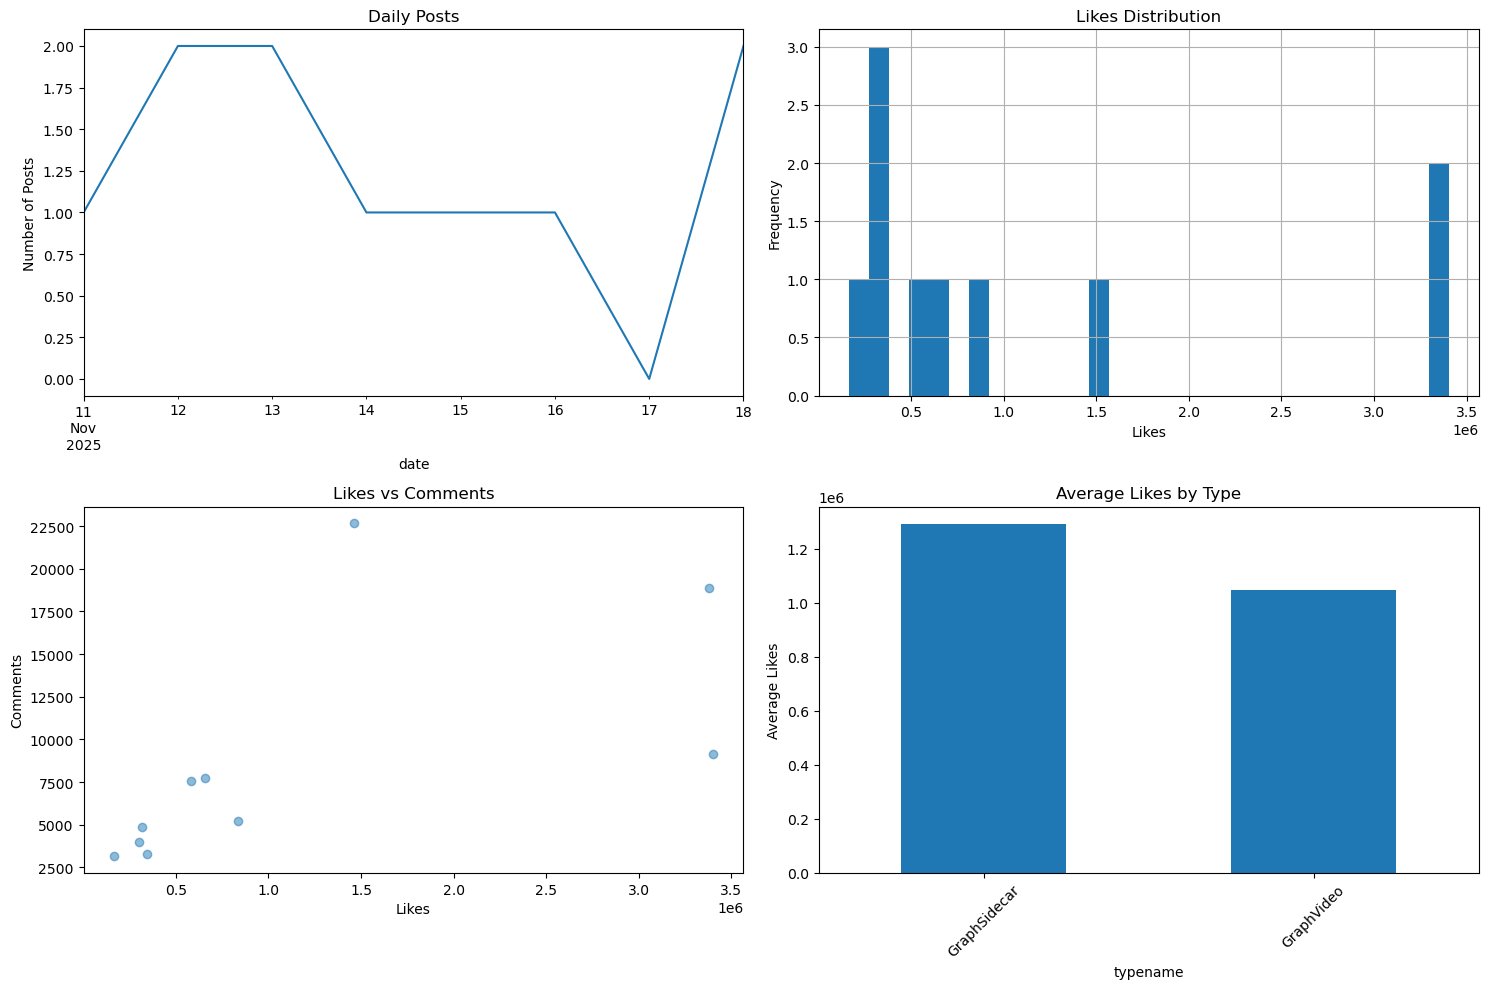

In [69]:
if not df_posts.empty and len(df_posts) > 1:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. 시간대별 게시글 수
    try:
        df_posts.set_index('date').resample('D').size().plot(ax=axes[0, 0], title='Daily Posts')
        axes[0, 0].set_ylabel('Number of Posts')
    except Exception as e:
        axes[0, 0].text(0.5, 0.5, f'오류: {str(e)[:30]}', ha='center')
    
    # 2. 좋아요 분포
    df_posts['likes'].hist(bins=30, ax=axes[0, 1])
    axes[0, 1].set_title('Likes Distribution')
    axes[0, 1].set_xlabel('Likes')
    axes[0, 1].set_ylabel('Frequency')
    
    # 3. 좋아요 vs 댓글
    axes[1, 0].scatter(df_posts['likes'], df_posts['comments'], alpha=0.5)
    axes[1, 0].set_title('Likes vs Comments')
    axes[1, 0].set_xlabel('Likes')
    axes[1, 0].set_ylabel('Comments')
    
    # 4. 타입별 평균 좋아요
    type_likes = df_posts.groupby('typename')['likes'].mean()
    if len(type_likes) > 0:
        type_likes.plot(kind='bar', ax=axes[1, 1])
        axes[1, 1].set_title('Average Likes by Type')
        axes[1, 1].set_ylabel('Average Likes')
        axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
else:
    print("시각화를 위한 충분한 데이터가 없습니다.")


### 6.4 해시태그 분석

=== 인기 해시태그 TOP 20 ===
#10Things: 2회
#InTheMoment: 2회
#InTheMoment⁣: 1회
#WhatsInMyCameraRoll,: 1회


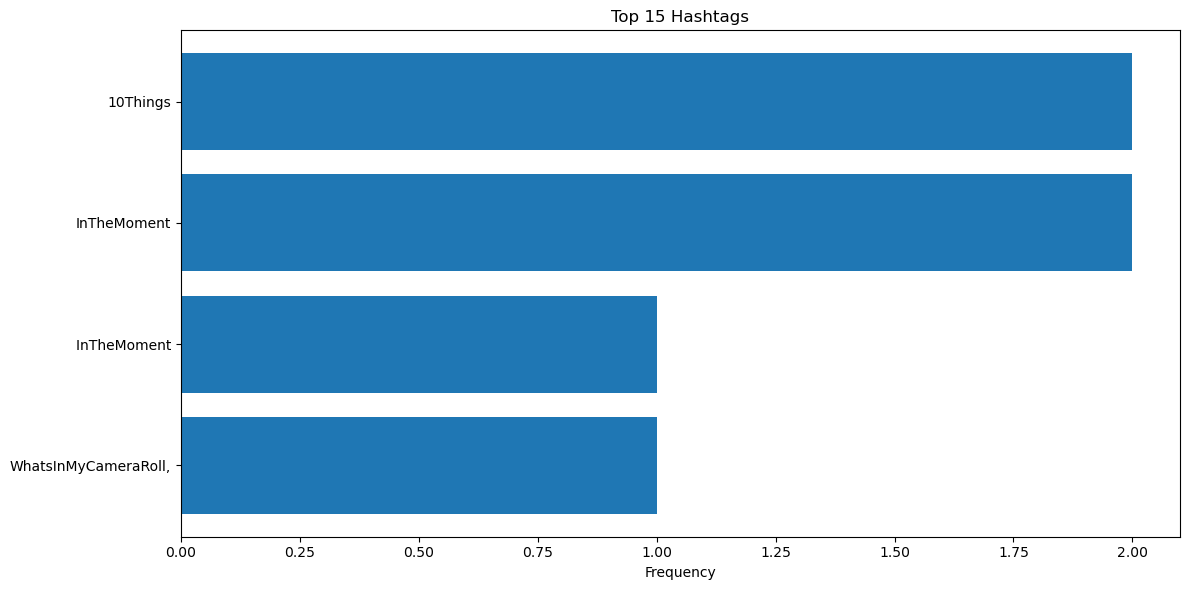

In [70]:
if not df_posts.empty:
    # 모든 해시태그 추출
    all_hashtags = []
    for hashtags in df_posts['hashtags']:
        if isinstance(hashtags, list):
            all_hashtags.extend(hashtags)
    
    if all_hashtags:
        # 빈도수 계산
        from collections import Counter
        hashtag_counts = Counter(all_hashtags)
        
        print("=== 인기 해시태그 TOP 20 ===")
        for hashtag, count in hashtag_counts.most_common(20):
            print(f"#{hashtag}: {count}회")
        
        # 시각화
        top_hashtags = dict(hashtag_counts.most_common(15))
        
        if len(top_hashtags) > 0:
            plt.figure(figsize=(12, 6))
            plt.barh(list(top_hashtags.keys()), list(top_hashtags.values()))
            plt.xlabel('Frequency')
            plt.title('Top 15 Hashtags')
            plt.gca().invert_yaxis()
            plt.tight_layout()
            plt.show()
    else:
        print("해시태그가 없습니다.")


### 6.5 시간대 분석

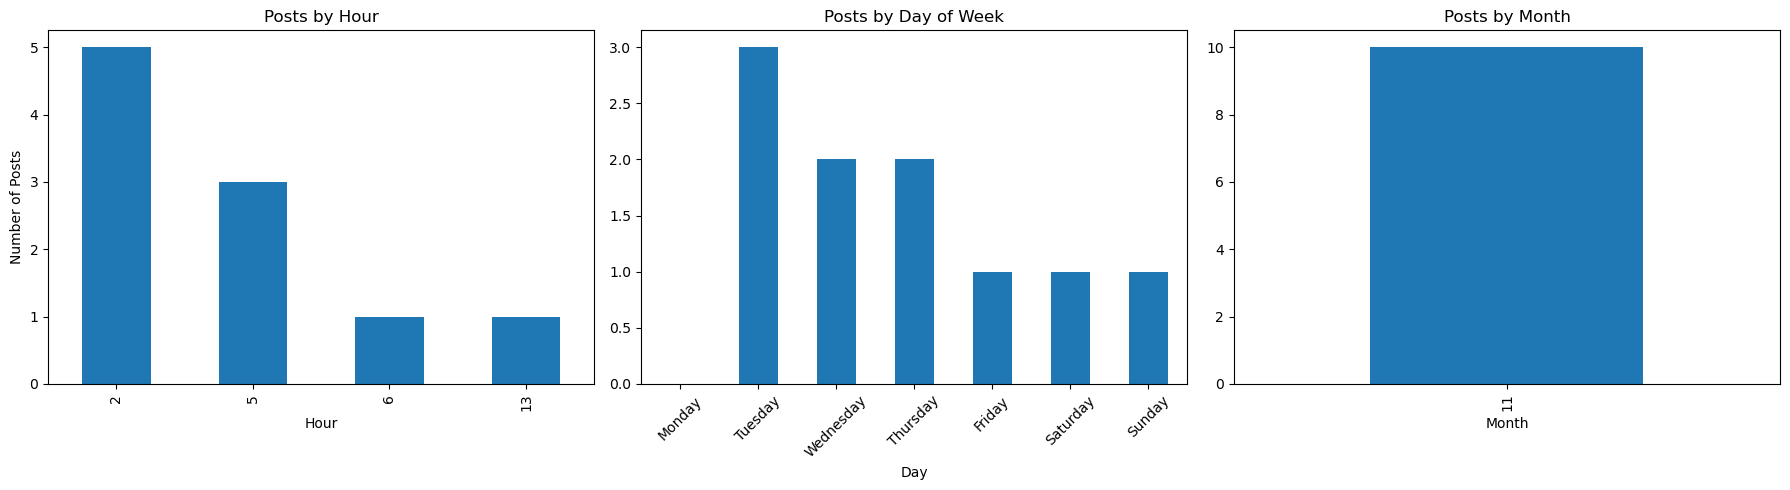


=== 가장 활발한 시간대 ===
시간: 2시
요일: Tuesday
월: 11월


In [71]:
if not df_posts.empty:
    # 시간대별 분석
    df_posts['hour'] = df_posts['date'].dt.hour
    df_posts['day_of_week'] = df_posts['date'].dt.day_name()
    df_posts['month'] = df_posts['date'].dt.month
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 시간대별 게시글 수
    hour_counts = df_posts['hour'].value_counts().sort_index()
    if len(hour_counts) > 0:
        hour_counts.plot(kind='bar', ax=axes[0])
        axes[0].set_title('Posts by Hour')
        axes[0].set_xlabel('Hour')
        axes[0].set_ylabel('Number of Posts')
    
    # 요일별 게시글 수
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_counts = df_posts['day_of_week'].value_counts().reindex(day_order)
    if len(day_counts) > 0:
        day_counts.plot(kind='bar', ax=axes[1])
        axes[1].set_title('Posts by Day of Week')
        axes[1].set_xlabel('Day')
        axes[1].tick_params(axis='x', rotation=45)
    
    # 월별 게시글 수
    month_counts = df_posts['month'].value_counts().sort_index()
    if len(month_counts) > 0:
        month_counts.plot(kind='bar', ax=axes[2])
        axes[2].set_title('Posts by Month')
        axes[2].set_xlabel('Month')
    
    plt.tight_layout()
    plt.show()
    
    # 통계 출력
    print("\n=== 가장 활발한 시간대 ===")
    if len(df_posts['hour'].mode()) > 0:
        print(f"시간: {df_posts['hour'].mode().values[0]:.0f}시")
    if len(df_posts['day_of_week'].mode()) > 0:
        print(f"요일: {df_posts['day_of_week'].mode().values[0]}")
    if len(df_posts['month'].mode()) > 0:
        print(f"월: {df_posts['month'].mode().values[0]:.0f}월")


### 6.6 DataFrame을 CSV로 저장

In [72]:
if not df_posts.empty:
    # CSV 저장 (해시태그는 문자열로 변환)
    df_export = df_posts.copy()
    df_export['hashtags'] = df_export['hashtags'].apply(lambda x: ','.join(x) if isinstance(x, list) and x else '')
    df_export['date'] = df_export['date'].dt.strftime('%Y-%m-%d %H:%M:%S')
    
    csv_path = WORK_DIR / "posts_analysis.csv"
    df_export.to_csv(csv_path, index=False, encoding='utf-8-sig')
    print(f"✓ CSV 저장 완료: {csv_path}")
    print(f"  총 {len(df_export)}개 게시글, {len(df_export.columns)}개 컬럼")
    
    # Excel로도 저장 (openpyxl 있을 때만)
    try:
        xlsx_path = WORK_DIR / "posts_analysis.xlsx"
        df_export.to_excel(xlsx_path, index=False, engine='openpyxl')
        print(f"✓ Excel 저장 완료: {xlsx_path}")
    except ImportError:
        print("⚠️ openpyxl이 설치되지 않았습니다. (pip install openpyxl)")


✓ CSV 저장 완료: ../instaloader_data/posts_analysis.csv
  총 10개 게시글, 16개 컬럼
✓ Excel 저장 완료: ../instaloader_data/posts_analysis.xlsx


---

## 7. 테스트

In [ ]:
L = instaloader.Instaloader(sleep=True) # Enable sleep between requests

In [ ]:
L.login(user="juhyeokcrawl02", passwd="maint!@#123")
L.save_session_to_file("session_file")

In [ ]:
import time
import instaloader

In [79]:
profile = instaloader.Profile.from_username(L.context, "nike")
for post in profile.get_posts():
    L.download_post(post, target="nike")
    time.sleep(2)  # 2초 대기

JSON Query to graphql/query: 401 Unauthorized - "fail" status, message "Please wait a few minutes before you try again." when accessing https://www.instagram.com/graphql/query [retrying; skip with ^C]
JSON Query to graphql/query: 401 Unauthorized - "fail" status, message "Please wait a few minutes before you try again." when accessing https://www.instagram.com/graphql/query?variables=%7B%22data%22%3A%7B%22count%22%3A12%2C%22include_relationship_info%22%3Atrue%2C%22latest_besties_reel_media%22%3Atrue%2C%22latest_reel_media%22%3Atrue%7D%2C%22username%22%3A%22nike%22%2C%22__relay_internal__pv__PolarisFeedShareMenurelayprovider%22%3Afalse%7D&doc_id=7898261790222653&server_timestamps=true [retrying; skip with ^C]


ConnectionException: JSON Query to graphql/query: 401 Unauthorized - "fail" status, message "Please wait a few minutes before you try again." when accessing https://www.instagram.com/graphql/query?variables=%7B%22data%22%3A%7B%22count%22%3A12%2C%22include_relationship_info%22%3Atrue%2C%22latest_besties_reel_media%22%3Atrue%2C%22latest_reel_media%22%3Atrue%7D%2C%22username%22%3A%22nike%22%2C%22__relay_internal__pv__PolarisFeedShareMenurelayprovider%22%3Afalse%7D&doc_id=7898261790222653&server_timestamps=true